# Support Vector Machine 
Using the Supervised Learning Algorithm

## Data

### Import the libraries 

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
path_folder = '../Dataset/wine_quality'
os.path.exists(path_folder)

True

### Importing the dataset

In [3]:
df_red = pd.read_csv(os.path.join(path_folder, 'winequality-red.csv'), sep=';', quotechar='"')
df_white = pd.read_csv(os.path.join(path_folder, 'winequality-white.csv'), sep=';', quotechar='"')

In [4]:
df_red.head()
#df_white.head()

,fixed acidity,"""volatile acidity""","""citric acid""","""residual sugar""","""chlorides""","""free sulfur dioxide""","""total sulfur dioxide""","""density""","""pH""","""sulphates""","""alcohol""","""quality"""
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df_red.info()
#df_white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fixed acidity            1599 non-null   float64
 1    "volatile acidity"      1599 non-null   float64
 2    "citric acid"           1599 non-null   float64
 3    "residual sugar"        1599 non-null   float64
 4    "chlorides"             1599 non-null   float64
 5    "free sulfur dioxide"   1599 non-null   float64
 6    "total sulfur dioxide"  1599 non-null   float64
 7    "density"               1599 non-null   float64
 8    "pH"                    1599 non-null   float64
 9    "sulphates"             1599 non-null   float64
 10   "alcohol"               1599 non-null   float64
 11   "quality"               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


### Union Dataset

Label the type of wines

In [6]:
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

In [7]:
df_red.columns = df_red.columns.str.strip().str.replace('"','')
df_white.columns = df_white.columns.str.strip().str.replace('"','')

df_wine: union of the two dataset

In [8]:
df_wines = pd.concat([df_red, df_white], ignore_index=True)

In [9]:
df_wines.columns = df_wines.columns.str.strip().str.replace('"','')

In [10]:
df_wines.shape

(6497, 13)

In [11]:
df_wines.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [12]:
df_wines['wine_type'].value_counts()

wine_type
white    4898
red      1599
Name: count, dtype: int64

## Cleaning data and Analyze features

In [13]:
df_red.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

In [14]:
df_white.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

In [15]:
df_wines.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

In [16]:
df_red.describe()
#df_wines.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Inline matplot and more

Section for matplot to display graph correctly and some adjustment on the data

In [20]:
%matplotlib inline

After this operation:
0 -> red wine
1 -> white wine

In [21]:
df_wines['wine_type'] = df_wines['wine_type'].map({'red': 0, 'white': 1})

In [22]:
df_red['wine_type'] = df_red['wine_type'].map({'red': 0})
df_white['wine_type'] = df_white['wine_type'].map({'white': 1})

## Which Dataset to use

In [23]:
df_to_use = df_wines.copy()

## Define label and correlation

### Labelling

In [24]:
df_to_use['quality_label'] = (df_to_use['quality'] >= 6).astype(int)

In [25]:
def label_quality(values):
    if values <= 5:
        return 0 #'low'
    elif values <= 6:
        return 1 #'med'
    else:
        return 2 #'high'
         

In [26]:
df_to_use['quality_label'] = df_to_use['quality'].apply(label_quality)

Total quantity for 'quality_label'

In [27]:
df_to_use['quality_label'].value_counts()

quality_label
1    2836
0    2384
2    1277
Name: count, dtype: int64

This subsection is used to define which variable influence more the target: 'quality'

In [28]:
#corr = df_wines.corr()
corr = df_to_use.drop(columns=['wine_type']).corr()

### Linear correlation between all variables

Correlation of Pearson [-1, +1]

+1 → perfetta correlazione positiva: al crescere di x, cresce quality

 0 → nessuna correlazione lineare

-1 → perfetta correlazione negativa: al crescere di x, quality diminuisce

<Axes: >

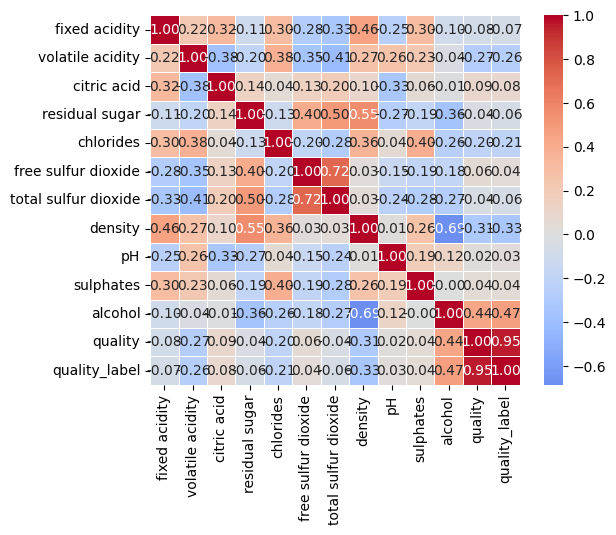

In [29]:
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

Which variabile influence more the 'quality'

In [30]:
correlation = df_to_use.corr()['quality'].drop(['quality', 'quality_label']).sort_values(ascending=False)
top_features = correlation.abs()

In [31]:
top_features.sort_values(ascending=False)
#correlation

alcohol                 0.444319
density                 0.305858
volatile acidity        0.265699
chlorides               0.200666
citric acid             0.085532
fixed acidity           0.076743
free sulfur dioxide     0.055463
total sulfur dioxide    0.041385
sulphates               0.038485
residual sugar          0.036980
pH                      0.019506
wine_type                    NaN
Name: quality, dtype: float64

## Feature selection

### Simplest one: choose a specific number

In [32]:
selected_features = top_features.sort_values(ascending=False).drop('wine_type').head(11).index.tolist()
#selected_features.remove('chlorides')
#selected_features.remove('fixed acidity') #FOR BINARY
#selected_features.remove('citric acid')
#selected_features.remove('pH')
#selected_features.remove('total sulfur dioxide')
#selected_features.remove('free sulfur dioxide')
#selected_features.remove('density')
#selected_features.remove('residual sugar')
#selected_features.remove('sulphates')
print(selected_features)

['alcohol', 'density', 'volatile acidity', 'chlorides', 'citric acid', 'fixed acidity', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'residual sugar', 'pH']


In [33]:
df_to_use.columns.tolist()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'wine_type',
 'quality_label']

## Target and Feature assignment

In [34]:
df_to_use.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,NaN,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,NaN,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,NaN,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,NaN,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,NaN,0


Separate Feature from Label

In [35]:
X = df_to_use.drop(['quality', 'quality_label', 'wine_type'], axis=1)
X_selected_features = df_to_use[selected_features]
y = df_to_use['quality_label']

In [36]:
y

0       0
1       0
2       0
3       1
4       0
       ..
6492    1
6493    0
6494    1
6495    2
6496    1
Name: quality_label, Length: 6497, dtype: int64

## Training and Test

Split and Standardization

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected_features, y, test_size=0.2, random_state=42
)

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Find the best parameter for the dataset

In [40]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform

In [ ]:
param_grid = {
    'C': uniform(0.1, 100), #[0.1, 1, 10, 100],
    'gamma': uniform(0.001, 1), #['scale', 0.01, 0.1, 0.95, 1],
    'kernel': ['rbf']
}

In [38]:
#grid = GridSearchCV(SVC(), param_grid=param_grid, refit=True, cv=5, scoring='accuracy')

grid = RandomizedSearchCV(SVC(), param_distributions=param_grid, refit=True, n_iter=30, cv=5, scoring='accuracy')



In [ ]:
grid.fit(X_train, y_train)

In [ ]:
print("Migliori parametri: ", grid.best_params_)

Migliori parametri:  {'C': np.float64(94.69099932877687), 'gamma': np.float64(0.9207256320029308), 'kernel': 'rbf'}


In [ ]:
print("Accuracy su test set: ", grid.score(X_test, y_test))

Accuracy su test set:  0.6738461538461539


In [ ]:
grid_c = grid.best_params_['C']
grid_gamma = grid.best_params_['gamma']
grid_kernel = grid.best_params_['kernel']

### Define the model, Train and Test

In [ ]:
model = SVC(kernel=grid_kernel, C=grid_c, gamma=grid_gamma, class_weight='balanced', probability=True)
#model = SVC(kernel='poly', C=1, gamma='scale', coef0=1.0, degree=3, class_weight='balanced', probability=True)

Train model on data-train

In [42]:
model.fit(X_train, y_train)

SVC(C=1, class_weight='balanced', coef0=1.0, kernel='poly', probability=True)

I support vectors sono i punti del training set più vicini all’iperpiano decisionale, quelli “decisivi” per la costruzione della frontiera.

Permette di capire quanto il tuo modello si affida a pochi punti chiave:

- Pochi support vectors → modello più semplice e generalizzabile.

- Molti support vectors → può indicare dati rumorosi o un margine difficile da trovare → rischio overfitting.

Elevati support vectors, possono indicare che tra le feature non vi sono delle forti relazioni lineare. Segue, kernel='rbf' risultano "migliori". Verifica tramite i test

In [43]:
print(f"Number of support vectors: {model.support_vectors_.shape[0]}")

Number of support vectors: 4072


In [44]:
model.score(X_test, y_test)

0.5584615384615385

Use the trained model and Test it

In [45]:
y_pred = model.predict(X_test)

In [46]:
print("Accuracy: ", accuracy_score(y_test, y_pred))


Accuracy:  0.5584615384615385


In [47]:
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Confusion Matrix: [[319 100  32]
 [196 230 171]
 [ 10  65 177]]


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.71      0.65       451
           1       0.58      0.39      0.46       597
           2       0.47      0.70      0.56       252

    accuracy                           0.56      1300
   macro avg       0.55      0.60      0.56      1300
weighted avg       0.57      0.56      0.55      1300



<Axes: >

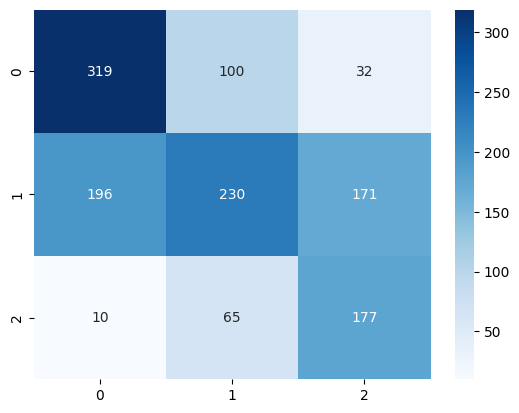

In [49]:
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', cmap='Blues')

## Cross-validation 

### cross-validation manual

In [50]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

Divide i dati in k parti, preservando le proporzioni delle classi. Ogni fold è rappresentativo del dataset

StratifiedKFold è un metodo per dividere i dati in K sottogruppi (fold), mantenendo la stessa distribuzione delle classi in ogni fold.

È fondamentale nei dataset sbilanciati (come nel tuo caso).

Parametri:

- n_splits=5: divide il dataset in 5 parti

- shuffle=True: mescola i dati prima di dividere → importante per evitare bias

- random_state=42: per avere risultati ripetibili

In [51]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [52]:
model_cv = SVC(
    kernel=grid_kernel,
    C=grid_c,
    #gamma=grid_gamma,
    class_weight='balanced',
    probability=True
)

NameError: name 'grid_kernel' is not defined

In [ ]:
accuracies = []
reports = []

X_selected_features: contiene solo le variabili più rilevanti, aumentando la probabilità che il modello sia più efficiente e generalizzabile.

In [ ]:
for train_idx, test_idx in skf.split(X_selected_features, y):
    # Dati divisi per fold
    X_train_cv = X_selected_features.iloc[train_idx]
    X_test_cv = X_selected_features.iloc[test_idx]
    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]

    # Normalizzazione sui dati di training
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_cv)
    X_test_scaled = scaler.transform(X_test_cv)

    # Allenamento e predizione
    model_cv.fit(X_train_scaled, y_train_cv)
    y_pred_cv = model_cv.predict(X_test_scaled)

    # Metriche
    acc_cv = accuracy_score(y_test_cv, y_pred_cv)
    accuracies.append(acc_cv)
    reports.append(classification_report(y_test_cv, y_pred_cv, output_dict=True))

In [ ]:
print(f"\nAccuracy avg: {np.mean(accuracies):.3f}")
print(f"Accuracy on fold: {[round(a, 3) for a in accuracies]}")


Accuracy avg: 0.634
Accuracy on fold: [0.635, 0.635, 0.634, 0.637, 0.629]


### cross_val_score

la cross_val_score: non deve essere eseguita; X_selected_features non è scalato.

Questo porta a:

- Mancanza di normalizzazione durante i fold.

- Il modello potrebbe dare risultati peggiori o incoerenti.

- (in questo caso )Non è data leakage, ma è una valutazione distorta rispetto a come hai addestrato il modello.

Il codice precedente effettua già la cross_val_score manualmente evitando il data-leakage.

Il Data-Leakage: accade quando un modello ha accesso a informazioni nel momento del training che non avrebbe nella realtà, cioè quando fa previsioni. Questo falsifica i risultati rendendo il modello artificialmente più accurato.

Esegue cross-validation: allena il modello 5 volte (una per ogni split), ogni volta con:

- fold per il training

- fold per il test

Alla fine restituisce una lista con 5 accuracy score, uno per ogni split.

In [ ]:
scores = cross_val_score(model, X_selected_features, y, cv=skf, scoring='accuracy')

Calcola la media degli score ottenuti nei 5 test → ti dà una stima più affidabile della performance del modello su dati mai visti.

In [ ]:
print(scores.mean())

0.7324920014472388


## Graphs Info

In [56]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

In [57]:
classes_label = [0, 1, 2]

### ROC Curve and AUC (for binary and multiclass classification)

#### Binary

In [314]:
y_scores = model.decision_function(X_test)

In [315]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

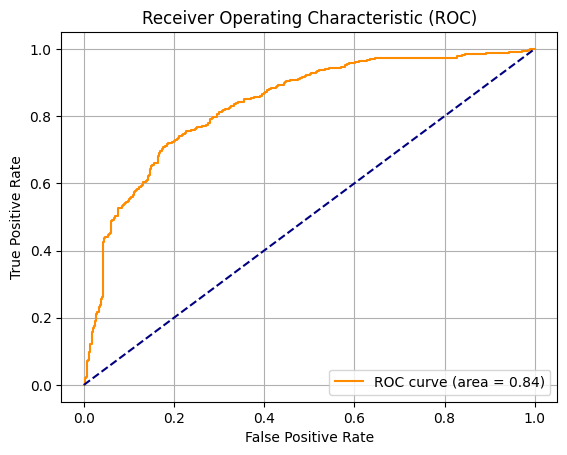

In [316]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid()

#### Multiclass

In [ ]:
y_test_bin = label_binarize(y_test, classes=classes_label)
y_score = model.decision_function(X_test)

# Calculate AUC for any calsses
auc_score = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print(f"Macro-average AUC (OvR): {auc_score:.3f}")

Macro-average AUC (OvR): 0.755


### Precision, Recall Curve

#### Binary

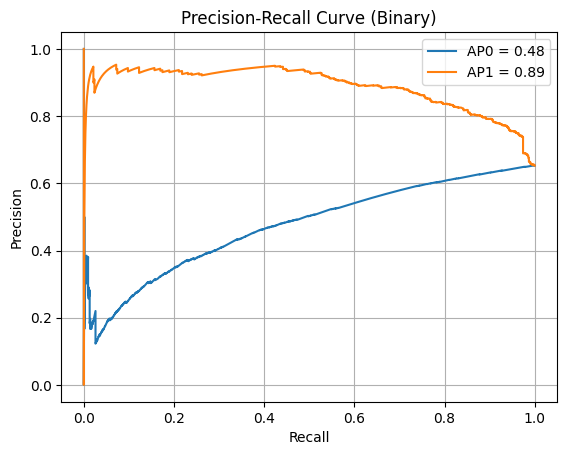

In [317]:
y_proba = model.predict_proba(X_test)[:, 1]
y_proba2 = model.predict_proba(X_test)[:, 0]

# Calculate PR Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

precision2, recall2, thresholds = precision_recall_curve(y_test, y_proba2)
ap2 = average_precision_score(y_test, y_proba2)

# Plot
plt.plot(recall2, precision2, label=f'AP0 = {ap2:.2f}')
plt.plot(recall, precision, label=f'AP1 = {ap:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Binary)')
plt.legend()
plt.grid(True)

#### Multiclass

In [59]:
y_test_bin = label_binarize(y_test, classes=classes_label)
y_proba = model.predict_proba(X_test)

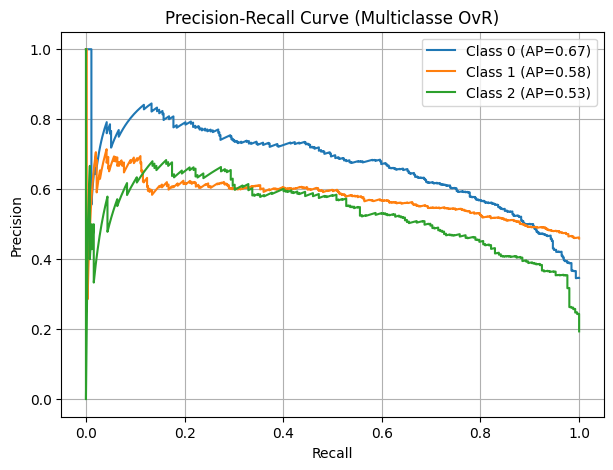

In [60]:
plt.figure(figsize=(7, 5))
for i in range(len(classes_label)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall, precision, label=f'Class {classes_label[i]} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Multiclasse OvR)')
plt.legend()
plt.grid(True)

## Wine_type - feature


Add the 'wine_type' can misleading the model to define the best quality based on the type of wine and the chimical characteristics

<Axes: xlabel='quality', ylabel='count'>

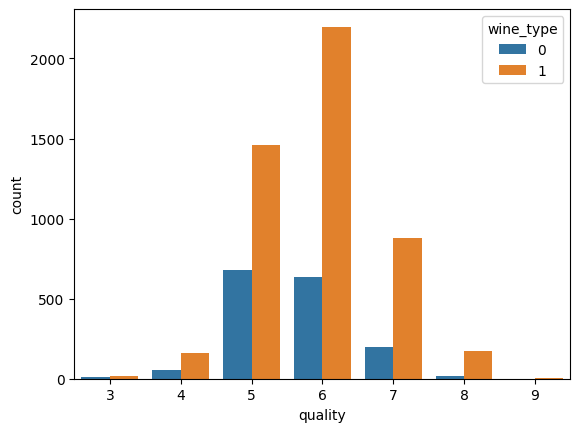

In [109]:
sns.countplot(data=df_to_use, x='quality', hue='wine_type')

## Permutation_importance

How important is a feature for a trained model

In [86]:
from sklearn.inspection import permutation_importance

In [87]:
result = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42)

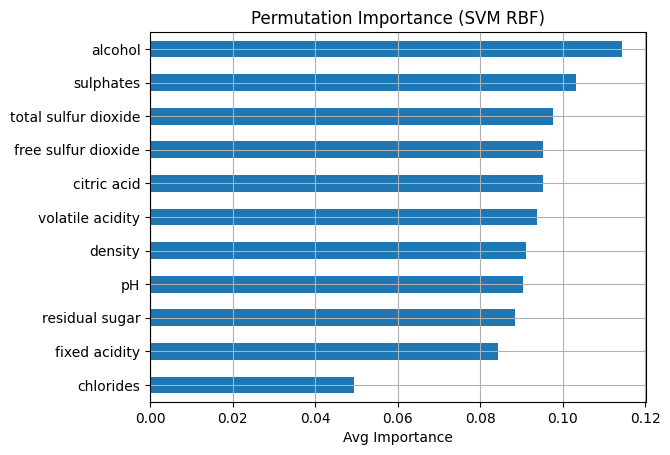

In [88]:
importances = pd.Series(result.importances_mean, index=selected_features)
importances.sort_values().plot(kind='barh')
plt.title("Permutation Importance (SVM RBF)")
plt.xlabel("Avg Importance")
plt.grid()